<a href="https://colab.research.google.com/github/mshendrikx/curso_ia_aval/blob/main/M1_Atividade_Avaliativa_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Avaliativa — Do tratamento dos dados ao uso de modelos de aprendizado de máquina

Esta atividade avalia se você consegue conduzir um fluxo básico de aprendizado de máquina, desde os dados brutos até a avaliação de modelos.

Nesta atividade avaliativa, você terá a opção de escolher uma das duas opções de tema para praticar o que foi ensinado desde o tratamento de dados ao uso de modelos de aprendizado de máquinas. **Basta escolher 1 opção (Tema 1 ou Tema 2) e submeter o código com sua resolução até o dia 01/07/2026**.

## Tema1: ABERTO - Você define a base de dados sobre a qual conduzirá sua análise.

Nesta opção, você trabalhará com uma base escolhida por você. Pode ser uma base pública, obtida no dataset Kaggle, ou outra fonte. Você deverá executar as atividades baseado no que foi proposto para o Tema 2, mas espero que consiga aprofundar ou mesmo inovar nas análises e aplicações a partir do que aprendeu no Módulo 1. Aproveite!!!


## Tema2: Análise de dados operacionais na indústria petrolífera


Você trabalhará com uma base sintética inspirada em registros operacionais de poços produtores em plataformas offshore.

A atividade foi planejada considerando uma turma com conhecimento **básico a intermediário em Python/Pandas** e em fase inicial de uso de **scikit-learn**. Por isso, várias células possuem códigos parcialmente preenchidos e comentários para guiar sua implementação.

## Objetivos

Ao final, você deverá ser capaz de:

1. Ler e inspecionar uma base de dados.
2. Tratar registros duplicados.
3. Corrigir inconsistências categóricas e numéricas.
4. Tratar valores faltantes por imputação.
5. Separar atributos e variáveis-alvo.
6. Aplicar transformações numéricas e categóricas.
7. Fazer seleção de atributos.
8. Treinar modelos de regressão e classificação.
9. Avaliar modelos com métricas adequadas.
10. Comparar modelos e justificar uma escolha final.

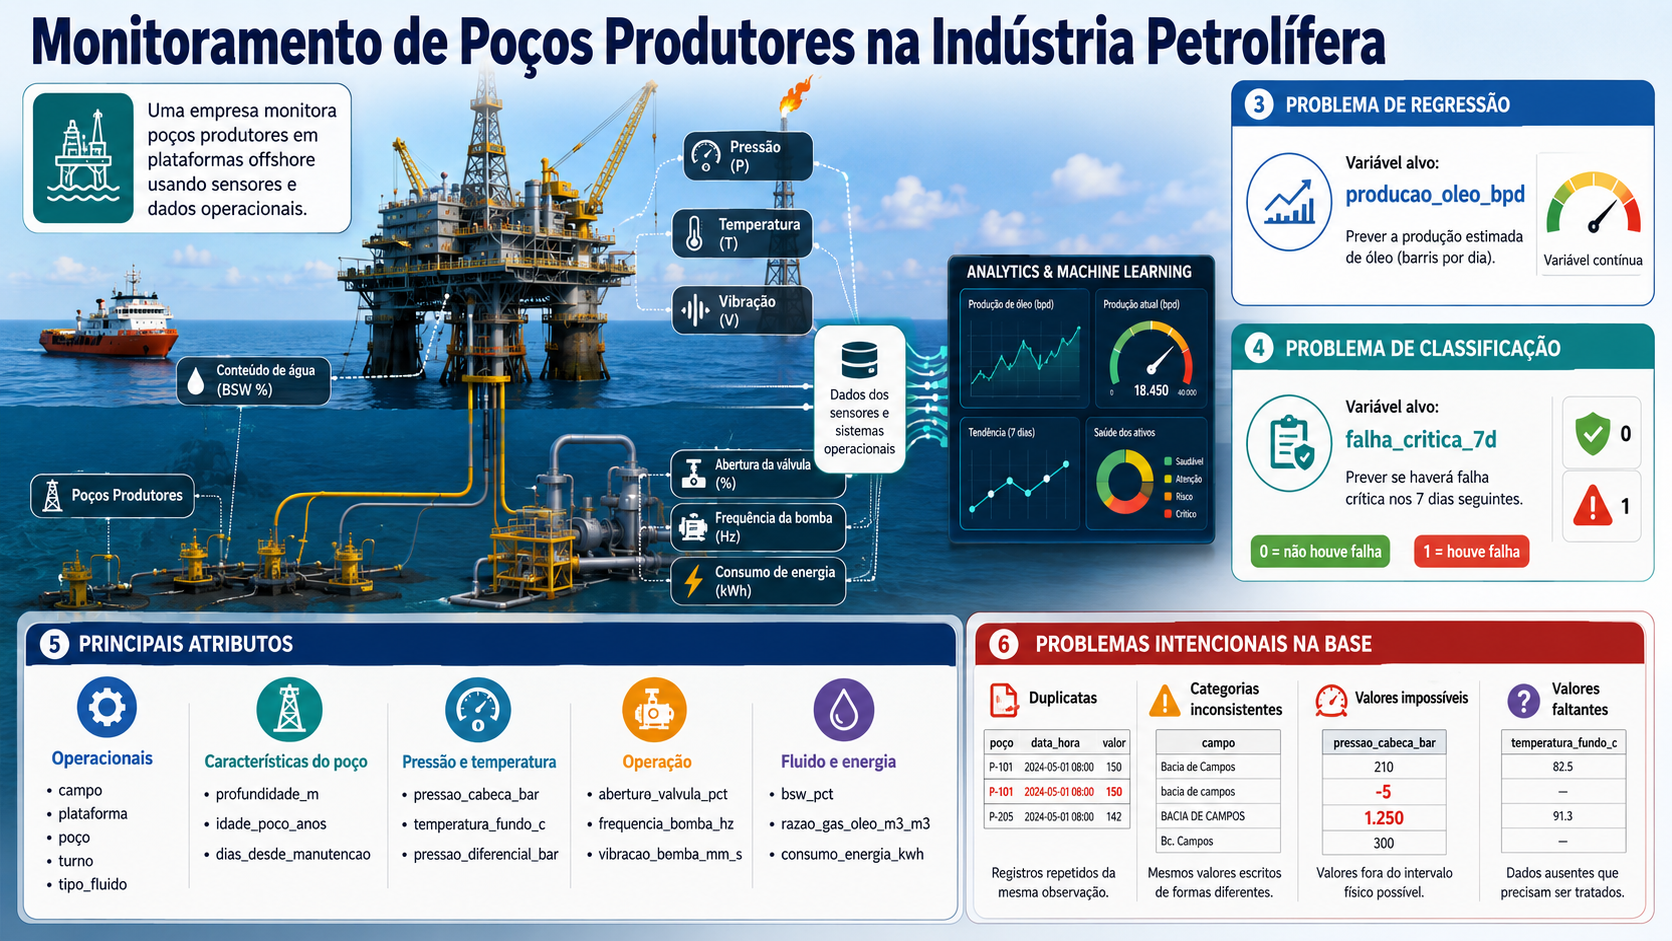

# 1. Contexto do problema industrial

Uma empresa da indústria petrolífera monitora poços produtores em diferentes plataformas offshore. Sensores instalados nos poços e sistemas de bombeamento registram variáveis operacionais como pressão, temperatura, vibração, teor de água e sedimentos, abertura de válvula, frequência da bomba e consumo de energia.

A equipe de engenharia deseja usar esses dados para dois objetivos.

## Problema de regressão

Prever:

- `producao_oleo_bpd`: produção estimada de óleo, em barris por dia.

Esse é um problema de **regressão**, pois o alvo é numérico contínuo.

## Problema de classificação

Prever:

- `falha_critica_7d`: indica se houve falha crítica nos 7 dias seguintes ao registro.

Esse é um problema de **classificação binária**, pois o alvo assume dois valores:

- `0`: não houve falha crítica;
- `1`: houve falha crítica.



## Principais atributos da base

| Coluna | Tipo | Descrição |
|---|---|---|
| `campo`, `plataforma`, `poco`, `turno`, `tipo_fluido` | Categóricas | Informações operacionais |
| `profundidade_m`, `idade_poco_anos`, `dias_desde_manutencao` | Numéricas | Características do poço |
| `pressao_cabeca_bar`, `temperatura_fundo_c`, `pressao_diferencial_bar` | Numéricas | Condições de pressão e temperatura |
| `abertura_valvula_pct`, `frequencia_bomba_hz`, `vibracao_bomba_mm_s` | Numéricas | Condições de operação |
| `bsw_pct`, `razao_gas_oleo_m3_m3`, `consumo_energia_kwh` | Numéricas | Características do fluido e energia |
| `producao_oleo_bpd` | Alvo de regressão | Produção de óleo |
| `falha_critica_7d` | Alvo de classificação | Falha crítica nos próximos 7 dias |

A base foi criada com problemas intencionais: duplicatas, categorias inconsistentes, valores impossíveis e valores faltantes.

# 2. Geração da base sintética

Execute a célula abaixo **sem alterar o código**.

Ela cria uma base sintética com problemas intencionais e salva o arquivo:

```python
dados_petroleo_sinteticos_sujos.csv
```

Depois, você deverá ler esse arquivo usando `pd.read_csv()`.

In [ ]:
# ------------------------------------------------------------
# 2) Geração da base sintética com problemas intencionais
# ------------------------------------------------------------

import numpy as np
import pandas as pd

rng = np.random.default_rng(123)
n = 720

datas = pd.date_range("2026-03-01", periods=n, freq="h")

plataforma_clean = rng.choice(["P-01", "P-02", "P-03", "P-04"], size=n, p=[0.32, 0.28, 0.24, 0.16])
campo_clean = np.where(
    np.isin(plataforma_clean, ["P-01", "P-02"]),
    "Bacia Norte",
    np.where(plataforma_clean == "P-03", "Bacia Sul", "Pre-Sal Leste")
)
turno_clean = rng.choice(["Manha", "Tarde", "Noite"], size=n, p=[0.38, 0.34, 0.28])
tipo_fluido_clean = rng.choice(["Oleo leve", "Oleo medio", "Oleo pesado"], size=n, p=[0.42, 0.36, 0.22])

pocos_por_plataforma = {
    "P-01": ["N-101", "N-102", "N-103", "N-104"],
    "P-02": ["N-201", "N-202", "N-203"],
    "P-03": ["S-301", "S-302", "S-303"],
    "P-04": ["L-401", "L-402"],
}

poco_clean = np.array([rng.choice(pocos_por_plataforma[p]) for p in plataforma_clean])

efeito_plataforma = {"P-01": 80, "P-02": 30, "P-03": -20, "P-04": 50}
efeito_fluido = {"Oleo leve": 80, "Oleo medio": 0, "Oleo pesado": -110}
profundidade_base = {"P-01": 2200, "P-02": 2500, "P-03": 1800, "P-04": 3100}

profundidade_m = np.array([profundidade_base[p] for p in plataforma_clean]) + rng.normal(0, 150, n)
idade_poco_anos = rng.uniform(1, 18, n)
dias_desde_manutencao = rng.integers(0, 240, n)

abertura_valvula_pct = rng.normal(68, 12, n)
frequencia_bomba_hz = rng.normal(52, 6, n)
bsw_pct = np.clip(rng.normal(22 + 1.2 * idade_poco_anos, 9, n), 2, 78)

pressao_cabeca_bar = np.clip(
    rng.normal(115 + 0.015 * profundidade_m - 0.18 * abertura_valvula_pct, 14, n),
    55,
    190
)

temperatura_fundo_c = np.clip(
    rng.normal(62 + 0.018 * profundidade_m, 8, n),
    70,
    140
)

razao_gas_oleo_m3_m3 = np.clip(rng.gamma(3.0, 38, n), 20, 330)

vibracao_bomba_mm_s = np.clip(
    rng.normal(2.4 + 0.007 * dias_desde_manutencao + 0.025 * frequencia_bomba_hz, 0.7, n),
    0.8,
    8.5
)

pressao_diferencial_bar = np.clip(pressao_cabeca_bar - rng.normal(45, 9, n), 15, 150)

consumo_energia_kwh = np.clip(
    420
    + 7.5 * frequencia_bomba_hz
    + 1.4 * pressao_diferencial_bar
    + 4.2 * vibracao_bomba_mm_s
    + rng.normal(0, 35, n),
    450,
    1100
)

producao_oleo_bpd = (
    280
    + 7.8 * abertura_valvula_pct
    + 9.5 * frequencia_bomba_hz
    - 5.2 * bsw_pct
    - 19 * vibracao_bomba_mm_s
    - 0.55 * dias_desde_manutencao
    - 0.055 * razao_gas_oleo_m3_m3
    + np.array([efeito_plataforma[p] for p in plataforma_clean])
    + np.array([efeito_fluido[t] for t in tipo_fluido_clean])
    + rng.normal(0, 70, n)
)

producao_oleo_bpd = np.clip(producao_oleo_bpd, 120, 1600)

z = (
    -5.8
    + 0.55 * vibracao_bomba_mm_s
    + 0.006 * dias_desde_manutencao
    + 0.018 * bsw_pct
    + 0.010 * np.maximum(0, pressao_cabeca_bar - 145)
    + 0.012 * np.maximum(0, consumo_energia_kwh - 850)
    - 0.002 * (producao_oleo_bpd - 650)
)

prob_falha = 1 / (1 + np.exp(-z))
falha_critica_7d = rng.binomial(1, prob_falha)

observacoes = rng.choice(
    ["operacao_normal", "verificar_bomba", "oscilacao_pressao", "sem_observacao", "ruido_sensor"],
    size=n,
    p=[0.52, 0.14, 0.12, 0.17, 0.05]
)

dados_limpos = pd.DataFrame({
    "id_registro": [f"REG-{i:05d}" for i in range(1, n + 1)],
    "data_coleta": datas,
    "campo": campo_clean,
    "plataforma": plataforma_clean,
    "poco": poco_clean,
    "turno": turno_clean,
    "tipo_fluido": tipo_fluido_clean,
    "profundidade_m": profundidade_m,
    "idade_poco_anos": idade_poco_anos,
    "dias_desde_manutencao": dias_desde_manutencao,
    "pressao_cabeca_bar": pressao_cabeca_bar,
    "temperatura_fundo_c": temperatura_fundo_c,
    "pressao_diferencial_bar": pressao_diferencial_bar,
    "abertura_valvula_pct": abertura_valvula_pct,
    "frequencia_bomba_hz": frequencia_bomba_hz,
    "vibracao_bomba_mm_s": vibracao_bomba_mm_s,
    "bsw_pct": bsw_pct,
    "razao_gas_oleo_m3_m3": razao_gas_oleo_m3_m3,
    "consumo_energia_kwh": consumo_energia_kwh,
    "observacao_operacional": observacoes,
    "producao_oleo_bpd": producao_oleo_bpd,
    "falha_critica_7d": falha_critica_7d
})

colunas_num = dados_limpos.select_dtypes(include="number").columns
dados_limpos[colunas_num] = dados_limpos[colunas_num].round(2)

dados_sujos = dados_limpos.copy()

# Datas em formatos mistos
dados_sujos["data_coleta"] = dados_sujos["data_coleta"].astype(str)
idx_datas = rng.choice(dados_sujos.index, size=50, replace=False)
for i in idx_datas[:25]:
    dados_sujos.loc[i, "data_coleta"] = pd.to_datetime(dados_sujos.loc[i, "data_coleta"]).strftime("%d/%m/%Y %H:%M")
for i in idx_datas[25:]:
    dados_sujos.loc[i, "data_coleta"] = pd.to_datetime(dados_sujos.loc[i, "data_coleta"]).strftime("%Y/%m/%d %H:%M")

# Categorias inconsistentes
idx = rng.choice(dados_sujos.index, size=80, replace=False)
for i in idx[:20]:
    dados_sujos.loc[i, "plataforma"] = dados_sujos.loc[i, "plataforma"].lower()
for i in idx[20:40]:
    dados_sujos.loc[i, "plataforma"] = dados_sujos.loc[i, "plataforma"].replace("-", " ")
for i in idx[40:55]:
    dados_sujos.loc[i, "turno"] = {"Manha": "manhã", "Tarde": "tarde ", "Noite": "NOITE"}[dados_sujos.loc[i, "turno"]]
for i in idx[55:70]:
    dados_sujos.loc[i, "campo"] = dados_sujos.loc[i, "campo"].upper()
for i in idx[70:]:
    dados_sujos.loc[i, "tipo_fluido"] = dados_sujos.loc[i, "tipo_fluido"].replace("Oleo", "Óleo")

# Valores faltantes
colunas_com_missing = [
    "pressao_cabeca_bar",
    "temperatura_fundo_c",
    "abertura_valvula_pct",
    "frequencia_bomba_hz",
    "vibracao_bomba_mm_s",
    "bsw_pct",
    "consumo_energia_kwh",
    "turno",
    "tipo_fluido"
]

for col in colunas_com_missing:
    idx_missing = rng.choice(dados_sujos.index, size=22, replace=False)
    dados_sujos.loc[idx_missing, col] = np.nan

# Valores fisicamente impossíveis
def inserir_valores(coluna, valores):
    idx_alt = rng.choice(dados_sujos.index, size=len(valores), replace=False)
    for i, valor in zip(idx_alt, valores):
        dados_sujos.loc[i, coluna] = valor

inserir_valores("pressao_cabeca_bar", [-20, 0, 480, 510])
inserir_valores("temperatura_fundo_c", [-10, 260, 310])
inserir_valores("abertura_valvula_pct", [-15, 125, 180])
inserir_valores("frequencia_bomba_hz", [-5, 0, 120])
inserir_valores("vibracao_bomba_mm_s", [-1, 22, 25])
inserir_valores("bsw_pct", [-8, 130, 160])
inserir_valores("consumo_energia_kwh", [-100, 2500, 3200])
inserir_valores("dias_desde_manutencao", [-3, 999])

# Duplicatas
duplicados = dados_sujos.sample(24, random_state=123)
dados_sujos = pd.concat([dados_sujos, duplicados], ignore_index=True)

# Embaralhamento
dados_sujos = dados_sujos.sample(frac=1, random_state=123).reset_index(drop=True)

nome_arquivo = "dados_petroleo_sinteticos_sujos.csv"
dados_sujos.to_csv(nome_arquivo, index=False)

print(f"Arquivo gerado: {nome_arquivo}")
print(f"Dimensão da base suja: {dados_sujos.shape}")
print(f"Taxa de falha crítica: {dados_sujos['falha_critica_7d'].mean():.2%}")

display(dados_sujos.head())

Arquivo gerado: dados_petroleo_sinteticos_sujos.csv
Dimensão da base suja: (744, 22)
Taxa de falha crítica: 24.60%


,id_registro,data_coleta,campo,plataforma,poco,turno,tipo_fluido,profundidade_m,idade_poco_anos,dias_desde_manutencao,...,pressao_diferencial_bar,abertura_valvula_pct,frequencia_bomba_hz,vibracao_bomba_mm_s,bsw_pct,razao_gas_oleo_m3_m3,consumo_energia_kwh,observacao_operacional,producao_oleo_bpd,falha_critica_7d
0,REG-00293,2026-03-13 04:00:00,Bacia Sul,P-03,S-301,Tarde,Oleo pesado,1746.42,14.12,71,...,80.69,85.37,59.40,3.94,55.96,115.67,1086.74,operacao_normal,1046.29,0
1,REG-00042,2026-03-02 17:00:00,Bacia Norte,P-02,N-203,Tarde,Oleo pesado,2412.96,5.68,181,...,108.59,102.19,54.04,6.02,27.18,49.29,951.07,verificar_bomba,1335.50,0
2,REG-00397,2026-03-17 12:00:00,Bacia Norte,P-02,N-203,Tarde,Oleo leve,2183.89,12.37,234,...,98.77,70.02,47.66,4.71,43.45,189.26,963.08,oscilacao_pressao,858.06,0
3,REG-00167,2026-03-07 22:00:00,Bacia Norte,P-01,N-104,Tarde,Oleo medio,2090.20,3.71,79,...,73.33,72.88,45.28,2.18,36.04,82.54,885.96,operacao_normal,994.25,0
4,REG-00600,2026-03-25 23:00:00,Bacia Norte,P-01,N-101,Tarde,Oleo leve,2280.09,7.80,122,...,84.97,81.77,44.27,4.75,33.47,83.03,938.00,verificar_bomba,1188.09,0


# 3. Leitura e inspeção inicial

Leia o arquivo CSV criado na etapa anterior.

Recursos úteis:

- `pd.read_csv(...)`: lê o arquivo CSV.
- `.head()`: mostra as primeiras linhas.
- `.shape`: mostra número de linhas e colunas.
- `.info()`: mostra tipos e valores não nulos.
- `.describe()`: resume variáveis numéricas.
- `.isna().sum()`: conta valores faltantes.

In [ ]:
# ------------------------------------------------------------
# 3) Leitura e inspeção inicial
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TODO: leia o arquivo CSV.
dados = pd.read_csv("dados_petroleo_sinteticos_sujos.csv")

print("Dimensões da base:", dados.shape)

display(dados.head())

dados.info()

display(dados.describe())

print("\nValores ausentes por coluna:")
display(dados.isna().sum().sort_values(ascending=False))

## Questão 1 — Diagnóstico inicial

Responda brevemente:

1. Quantas linhas e colunas a base possui inicialmente?
2. Quais colunas possuem valores ausentes?
3. Você identificou valores muito estranhos em alguma variável numérica?
4. Quais colunas parecem ser identificadores ou textos livres e, portanto, provavelmente não devem entrar diretamente no modelo?

**Resposta do aluno:**

-

# 4. Tratamento de dados duplicados

Registros duplicados podem distorcer estatísticas e influenciar o treinamento dos modelos.

Nesta etapa, você deverá:

1. Contar quantas linhas duplicadas existem.
2. Remover duplicatas.
3. Verificar a nova dimensão da base.

Recursos úteis:

- `.duplicated().sum()`;
- `.drop_duplicates()`;
- `.copy()`.

In [ ]:
# ------------------------------------------------------------
# 4) Tratamento de duplicados
# ------------------------------------------------------------

dados_tratados = dados.copy()

# TODO: conte duplicatas.
qtd_duplicados = dados_tratados.duplicated().sum()
print("Quantidade de registros duplicados:", qtd_duplicados)

# TODO: remova duplicatas.
dados_tratados = dados_tratados.drop_duplicates()

print("Dimensão após remoção de duplicados:", dados_tratados.shape)

## Interpretação

Após remover duplicatas, explique se a quantidade de registros mudou. Por que duplicatas podem ser um problema em aprendizado de máquina?

**Resposta do aluno:**

-

# 5. Tratamento de inconsistências categóricas

Algumas categorias foram escritas de formas diferentes. Por exemplo:

- `P-01`, `p-01`, `P 01`;
- `Manha`, `manhã`, `tarde `, `NOITE`;
- `Oleo leve`, `Óleo leve`.

Recursos úteis:

- `.str.strip()`;
- `.str.lower()`;
- `.replace({...})`;
- `.value_counts()`;
- `.unique()`.

Esta etapa não usa informação do alvo. Portanto, pode ser feita antes da separação treino/teste.

In [ ]:
# ------------------------------------------------------------
# 5) Diagnóstico de categorias inconsistentes
# ------------------------------------------------------------

colunas_categoricas = ["campo", "plataforma", "poco", "turno", "tipo_fluido"]

for col in colunas_categoricas:
    print(f"\nValores únicos em {col}:")
    print(dados_tratados[col].dropna().unique())

In [ ]:
# ------------------------------------------------------------
# 6) Padronização de categorias
# ------------------------------------------------------------

# Exemplo para plataforma:
mapa_plataforma = {
    "p-01": "P-01", "p 01": "P-01", "P 01": "P-01",
    "p-02": "P-02", "p 02": "P-02", "P 02": "P-02",
    "p-03": "P-03", "p 03": "P-03", "P 03": "P-03",
    "p-04": "P-04", "p 04": "P-04", "P 04": "P-04"
}

dados_tratados["plataforma"] = (
    dados_tratados["plataforma"]
    .astype("string")
    .str.strip()
    .replace(mapa_plataforma)
)

# TODO: complete os mapas abaixo.
mapa_turno = {
    "manhã": "Manha",
    "Manhã": "Manha",
    "NOITE": "Noite",
    "noite": "Noite",
    "tarde": "Tarde",
    "tarde": "Tarde"
}

dados_tratados["turno"] = (
    dados_tratados["turno"]
    .astype("string")
    .str.strip()
    .replace(mapa_turno)
)

mapa_tipo_fluido = {
    "Óleo leve": "Oleo leve",
    "Óleo medio": "Oleo medio",
    "Óleo pesado": "Oleo pesado"
}

dados_tratados["tipo_fluido"] = (
    dados_tratados["tipo_fluido"]
    .astype("string")
    .str.strip()
    .replace(mapa_tipo_fluido)
)

mapa_campo = {
    "BACIA NORTE": "Bacia Norte",
    "BACIA SUL": "Bacia Sul",
    "PRE-SAL LESTE": "Pre-Sal Leste"
}

dados_tratados["campo"] = (
    dados_tratados["campo"]
    .astype("string")
    .str.strip()
    .replace(mapa_campo)
)

for col in ["campo", "plataforma", "turno", "tipo_fluido"]:
    print(f"\nCategorias após tratamento em {col}:")
    print(dados_tratados[col].value_counts(dropna=False))

## Interpretação

Explique quais inconsistências categóricas você encontrou e como decidiu padronizá-las.

**Resposta do aluno:**

-

# 6. Tratamento de inconsistências numéricas

Algumas variáveis possuem valores impossíveis ou muito improváveis, como pressão negativa, BSW acima de 100% ou abertura de válvula maior que 100%.

A estratégia será:

1. Definir limites plausíveis.
2. Substituir valores fora dos limites por `np.nan`.
3. Imputar esses valores posteriormente dentro do pipeline.

Recursos úteis:

- `.loc[condicao, coluna] = np.nan`;
- operadores lógicos `<`, `>`, `|`, `&`.

In [ ]:
# ------------------------------------------------------------
# 7) Tratamento de valores numéricos impossíveis
# ------------------------------------------------------------

limites_plausiveis = {
    "pressao_cabeca_bar": (40, 220),
    "temperatura_fundo_c": (50, 170),
    "abertura_valvula_pct": (0, 100),
    "frequencia_bomba_hz": (20, 80),
    "vibracao_bomba_mm_s": (0, 12),
    "bsw_pct": (0, 100),
    "consumo_energia_kwh": (300, 1500),
    "dias_desde_manutencao": (0, 365),
    "idade_poco_anos": (0, 40),
    "profundidade_m": (500, 5000),
    "pressao_diferencial_bar": (0, 200),
    "razao_gas_oleo_m3_m3": (0, 600)
}

for coluna, (limite_inferior, limite_superior) in limites_plausiveis.items():
    condicao_invalida = (dados_tratados[coluna] < limite_inferior) | (dados_tratados[coluna] > limite_superior)
    qtd_invalidos = condicao_invalida.sum()
    dados_tratados.loc[condicao_invalida, coluna] = np.nan
    print(f"{coluna}: {qtd_invalidos} valores inválidos substituídos por NaN")

print("\nValores ausentes após tratamento de inconsistências:")
display(dados_tratados.isna().sum().sort_values(ascending=False))

## Interpretação

Explique por que, em vez de remover todas as linhas com valores inválidos, substituímos esses valores por `NaN` para posterior imputação.

**Resposta do aluno:**

-

# 7. Separação dos problemas de regressão e classificação

Agora vamos preparar os dados para dois problemas.

## Regressão

Alvo:

```python
producao_oleo_bpd
```

Métricas:

- MAE;
- RMSE;
- R².

## Classificação

Alvo:

```python
falha_critica_7d
```

Métricas:

- acurácia;
- precisão;
- recall;
- F1-score;
- AUC.

## Atenção sobre data leakage

Não use a variável-alvo como atributo de entrada.

Também remova colunas que são identificadores ou texto livre, como:

- `id_registro`;
- `data_coleta`;
- `observacao_operacional`.

In [ ]:
# ------------------------------------------------------------
# 8) Definição de alvos e atributos
# ------------------------------------------------------------

alvo_regressao = "producao_oleo_bpd"
alvo_classificacao = "falha_critica_7d"

colunas_remover_reg = [
    "id_registro",
    "data_coleta",
    "observacao_operacional",
    alvo_regressao,
    alvo_classificacao
]

colunas_remover_clf = [
    "id_registro",
    "data_coleta",
    "observacao_operacional",
    alvo_classificacao,
    # Recomendação didática: remover o alvo de regressão para não usar uma "resposta" de outro problema como atributo.
    alvo_regressao
]

X_reg = dados_tratados.drop(columns=colunas_remover_reg)
y_reg = dados_tratados[alvo_regressao]

X_clf = dados_tratados.drop(columns=colunas_remover_clf)
y_clf = dados_tratados[alvo_classificacao]

print("X_reg:", X_reg.shape)
print("y_reg:", y_reg.shape)
print("X_clf:", X_clf.shape)
print("y_clf:", y_clf.shape)

display(X_reg.head())

# 8. Separação treino/teste

A separação entre treino e teste é fundamental para avaliar generalização.

Use:

- `test_size=0.25`;
- `random_state=42`;
- `stratify=y_clf` no problema de classificação.

O parâmetro `stratify` preserva a proporção das classes no treino e no teste.

In [ ]:
# ------------------------------------------------------------
# 9) Separação treino/teste
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.25,
    random_state=42,
    stratify=y_clf
)

print("Regressão:")
print("Treino:", X_train_reg.shape, "Teste:", X_test_reg.shape)

print("\nClassificação:")
print("Treino:", X_train_clf.shape, "Teste:", X_test_clf.shape)
print("\nProporção da classe 1 no treino:", y_train_clf.mean().round(3))
print("Proporção da classe 1 no teste:", y_test_clf.mean().round(3))

## Interpretação

Explique por que fazemos a separação treino/teste antes de imputar valores, escalonar variáveis e selecionar atributos.

**Resposta do aluno:**

-

# 9. Pré-processamento com imputação e transformação de dados

Como temos variáveis numéricas e categóricas, usaremos tratamentos diferentes.

## Variáveis numéricas

- imputação pela mediana;
- padronização com `StandardScaler`.

## Variáveis categóricas

- imputação pela categoria mais frequente;
- transformação com `OneHotEncoder`.

Recursos usados:

- `SimpleImputer(strategy="median")`;
- `SimpleImputer(strategy="most_frequent")`;
- `StandardScaler()`;
- `OneHotEncoder(handle_unknown="ignore")`;
- `ColumnTransformer`;
- `Pipeline`.

Como essas etapas estarão dentro do pipeline, o ajuste ocorrerá somente nos dados de treino, ajudando a evitar data leakage.

In [ ]:
# ------------------------------------------------------------
# 10) Pré-processamento para variáveis numéricas e categóricas
# ------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

atributos_numericos_reg = list(X_train_reg.select_dtypes(include="number").columns)
atributos_categoricos_reg = list(X_train_reg.select_dtypes(exclude="number").columns)

atributos_numericos_clf = list(X_train_clf.select_dtypes(include="number").columns)
atributos_categoricos_clf = list(X_train_clf.select_dtypes(exclude="number").columns)

print("Atributos numéricos - regressão:", atributos_numericos_reg)
print("Atributos categóricos - regressão:", atributos_categoricos_reg)

transformador_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("padronizador", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessador_reg = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, atributos_numericos_reg),
        ("cat", transformador_categorico, atributos_categoricos_reg)
    ]
)

preprocessador_clf = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, atributos_numericos_clf),
        ("cat", transformador_categorico, atributos_categoricos_clf)
    ]
)

print("Pré-processadores criados com sucesso.")

# 10. Seleção de atributos

A seleção de atributos busca reduzir o conjunto de variáveis usadas pelo modelo.

Usaremos:

- `SelectKBest`;
- `f_regression` para regressão;
- `f_classif` para classificação.

Como as variáveis categóricas passam por One-Hot Encoding, a seleção será aplicada **depois do pré-processamento**.

A seleção será colocada dentro do pipeline para que seja ajustada somente no conjunto de treino.

In [ ]:
# ------------------------------------------------------------
# 11) Seleção de atributos
# ------------------------------------------------------------

from sklearn.feature_selection import SelectKBest, f_regression, f_classif

# TODO: teste valores diferentes para k e compare os resultados.
k_reg = 12
k_clf = 12

print("k_reg =", k_reg)
print("k_clf =", k_clf)

# 11. Funções de avaliação

Para evitar repetição de código, criaremos funções simples para avaliar modelos.

## Regressão

- MAE;
- RMSE;
- R².

## Classificação

- acurácia;
- precisão;
- recall;
- F1-score;
- AUC.

In [ ]:
# ------------------------------------------------------------
# 12) Funções de avaliação
# ------------------------------------------------------------

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def avaliar_regressao(nome_modelo, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    return {
        "modelo": nome_modelo,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

def avaliar_classificacao(nome_modelo, y_real, y_pred, y_score=None):
    acuracia = accuracy_score(y_real, y_pred)
    precisao = precision_score(y_real, y_pred, zero_division=0)
    recall = recall_score(y_real, y_pred, zero_division=0)
    f1 = f1_score(y_real, y_pred, zero_division=0)

    if y_score is not None:
        auc = roc_auc_score(y_real, y_score)
    else:
        auc = np.nan

    return {
        "modelo": nome_modelo,
        "acuracia": acuracia,
        "precisao": precisao,
        "recall": recall,
        "f1_score": f1,
        "AUC": auc
    }

print("Funções de avaliação criadas.")

# 12. Modelos de regressão

Treine modelos para prever:

```python
producao_oleo_bpd
```

Use pelo menos três modelos:

1. Regressão Linear;
2. Ridge;
3. Lasso.

Opcionalmente, teste também:

4. Árvore de Decisão para regressão;
5. Floresta Aleatória para regressão.

Cada modelo deverá usar um pipeline com:

1. pré-processamento;
2. seleção de atributos;
3. modelo.

In [ ]:
# ------------------------------------------------------------
# 13) Modelos de regressão
# ------------------------------------------------------------

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

modelos_regressao = {
    "Regressao Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.05, max_iter=20000),
    "Arvore Regressao": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest Regressao": RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)
}

resultados_regressao = []

for nome, modelo in modelos_regressao.items():

    pipeline_reg = Pipeline(steps=[
        ("preprocessamento", preprocessador_reg),
        ("selecao", SelectKBest(score_func=f_regression, k=k_reg)),
        ("modelo", modelo)
    ])

    # TODO: treine o pipeline.
    pipeline_reg.fit(X_train_reg, y_train_reg)

    # TODO: gere previsões.
    pred_reg = pipeline_reg.predict(X_test_reg)

    # TODO: avalie o modelo.
    metricas = avaliar_regressao(nome, y_test_reg, pred_reg)
    resultados_regressao.append(metricas)

tabela_regressao = pd.DataFrame(resultados_regressao).sort_values("RMSE")
display(tabela_regressao)

## Interpretação dos modelos de regressão

Responda:

1. Qual modelo teve menor MAE?
2. Qual modelo teve menor RMSE?
3. Qual modelo teve maior R²?
4. O melhor modelo é necessariamente o mais complexo?
5. No contexto da produção de óleo, o que significa um erro MAE alto?

**Resposta do aluno:**

-

# 13. Modelos de classificação

Treine modelos para prever:

```python
falha_critica_7d
```

Use pelo menos três modelos:

1. Regressão Logística;
2. Árvore de Decisão;
3. Floresta Aleatória.

Opcionalmente, teste XGBoost, se disponível.

Em problemas de falha crítica, observe especialmente o **recall** da classe crítica.

In [ ]:
# ------------------------------------------------------------
# 14) Modelos de classificação
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

modelos_classificacao = {
    "Regressao Logistica": LogisticRegression(max_iter=20000),
    "Arvore Classificacao": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest Classificacao": RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1)
}

# Opcional: XGBoost
# from xgboost import XGBClassifier
# modelos_classificacao["XGBoost Classificacao"] = XGBClassifier(
#     n_estimators=120,
#     learning_rate=0.06,
#     max_depth=3,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     eval_metric="logloss",
#     random_state=42,
#     n_jobs=-1
# )

resultados_classificacao = []
pipelines_classificacao = {}

for nome, modelo in modelos_classificacao.items():

    pipeline_clf = Pipeline(steps=[
        ("preprocessamento", preprocessador_clf),
        ("selecao", SelectKBest(score_func=f_classif, k=k_clf)),
        ("modelo", modelo)
    ])

    # TODO: treine o pipeline.
    pipeline_clf.fit(X_train_clf, y_train_clf)

    # TODO: faça a predição de classes.
    pred_clf = pipeline_clf.predict(X_test_clf)

    # TODO: obtenha probabilidades para AUC, quando possível.
    if hasattr(pipeline_clf, "predict_proba"):
        score_clf = pipeline_clf.predict_proba(X_test_clf)[:, 1]
    else:
        score_clf = None

    metricas = avaliar_classificacao(nome, y_test_clf, pred_clf, score_clf)
    resultados_classificacao.append(metricas)

    pipelines_classificacao[nome] = pipeline_clf

tabela_classificacao = pd.DataFrame(resultados_classificacao).sort_values("f1_score", ascending=False)
display(tabela_classificacao)

## Interpretação dos modelos de classificação

Responda:

1. Qual modelo teve maior acurácia?
2. Qual modelo teve maior recall?
3. Qual modelo teve maior F1-score?
4. Qual modelo teve maior AUC?
5. Em um problema de falha crítica, você escolheria o modelo apenas pela acurácia? Justifique.

**Resposta do aluno:**

-

# 14. Matriz de confusão e relatório de classificação

Escolha o melhor modelo de classificação segundo um critério justificado.

Depois, gere:

- matriz de confusão;
- relatório de classificação.

Em problemas de falha crítica, falsos negativos podem ser especialmente preocupantes, pois representam casos críticos que o modelo não detectou.

In [ ]:
# ------------------------------------------------------------
# 15) Matriz de confusão do modelo escolhido
# ------------------------------------------------------------

# TODO: escolha o modelo que deseja analisar.
modelo_escolhido = "Regressao Logistica"

pipeline_escolhido = pipelines_classificacao[modelo_escolhido]
pred_escolhido = pipeline_escolhido.predict(X_test_clf)

matriz = confusion_matrix(y_test_clf, pred_escolhido)

print("Matriz de confusão:")
display(pd.DataFrame(
    matriz,
    index=["Real 0", "Real 1"],
    columns=["Previsto 0", "Previsto 1"]
))

print("\nRelatório de classificação:")
print(classification_report(
    y_test_clf,
    pred_escolhido,
    target_names=["Sem falha crítica", "Falha crítica"],
    zero_division=0
))

## Interpretação da matriz de confusão

Responda:

1. Quantos casos de falha crítica o modelo acertou?
2. Quantos casos críticos o modelo deixou passar?
3. Esse resultado seria aceitável em um cenário real? Justifique.

**Resposta do aluno:**

-

# 15. Curva ROC e AUC

A curva ROC mostra a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos.

A AUC resume a capacidade do modelo de separar as classes.

Recursos úteis:

- `roc_curve`;
- `roc_auc_score`;
- `predict_proba(X_test)[:, 1]`.

In [ ]:
# ------------------------------------------------------------
# 16) Curva ROC do modelo escolhido
# ------------------------------------------------------------

from sklearn.metrics import roc_curve, roc_auc_score

score_escolhido = pipeline_escolhido.predict_proba(X_test_clf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_clf, score_escolhido)
auc_escolhido = roc_auc_score(y_test_clf, score_escolhido)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{modelo_escolhido} | AUC = {auc_escolhido:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Classificador aleatório")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()

## Interpretação da curva ROC

Explique o que a AUC obtida indica sobre o modelo escolhido.

**Resposta do aluno:**

-

# 16. Comparação final e seleção de modelos

## Para regressão

Escolha um modelo para prever `producao_oleo_bpd`.

Considere:

- MAE;
- RMSE;
- R²;
- simplicidade do modelo;
- interpretação no contexto industrial.

## Para classificação

Escolha um modelo para prever `falha_critica_7d`.

Considere:

- acurácia;
- precisão;
- recall;
- F1-score;
- AUC;
- custo de falsos negativos em falhas críticas.

## Conclusão do aluno

### Melhor modelo de regressão escolhido

- Modelo:
- Justificativa:

### Melhor modelo de classificação escolhido

- Modelo:
- Justificativa:

### Principais aprendizados da atividade

-

# 17. Critérios sugeridos de avaliação

| Critério | Pontos |
|---|---:|
| Leitura, inspeção e diagnóstico inicial da base | 10 |
| Tratamento de duplicados e inconsistências categóricas | 15 |
| Tratamento de inconsistências numéricas | 15 |
| Estratégia correta de imputação e transformação | 15 |
| Separação adequada entre regressão e classificação | 10 |
| Uso correto de modelos de regressão e métricas | 10 |
| Uso correto de modelos de classificação e métricas | 10 |
| Seleção de atributos sem data leakage | 10 |
| Interpretação final e justificativa dos modelos escolhidos | 5 |
| **Total** | **100** |